# Finding Similar Items Assignment - Netflix Titles

This notebook focuses on two main goals:
1. **EDA (Exploratory Data Analysis)** to understand data structure, quality, and patterns.
2. **Finding Similar Items** using a content-based approach with text representation and cosine similarity.

Dataset: `dataset/netflix_titles.csv`

## Workflow

1. Load data and run data quality checks (missing values, duplicates, data types).
2. EDA: distribution of content type, rating, country, release year, and genre.
3. Data preparation for similarity: combine key text features.
4. TF-IDF vectorization + cosine similarity matrix.
5. Build a similar-title recommendation function and test sample queries.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Load dataset
DATA_PATH = 'dataset/netflix_titles.csv'
df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Shape: (8807, 12)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Quick data quality checks
missing = df.isna().sum().sort_values(ascending=False)
missing_ratio = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_ratio
})

dup_show_id = df.duplicated(subset=['show_id']).sum()
dup_title_year = df.duplicated(subset=['title', 'release_year']).sum()

print('Duplicate show_id:', dup_show_id)
print('Duplicate title+release_year:', dup_title_year)
quality

Duplicate show_id: 0
Duplicate title+release_year: 0


,missing_count,missing_pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


## EDA

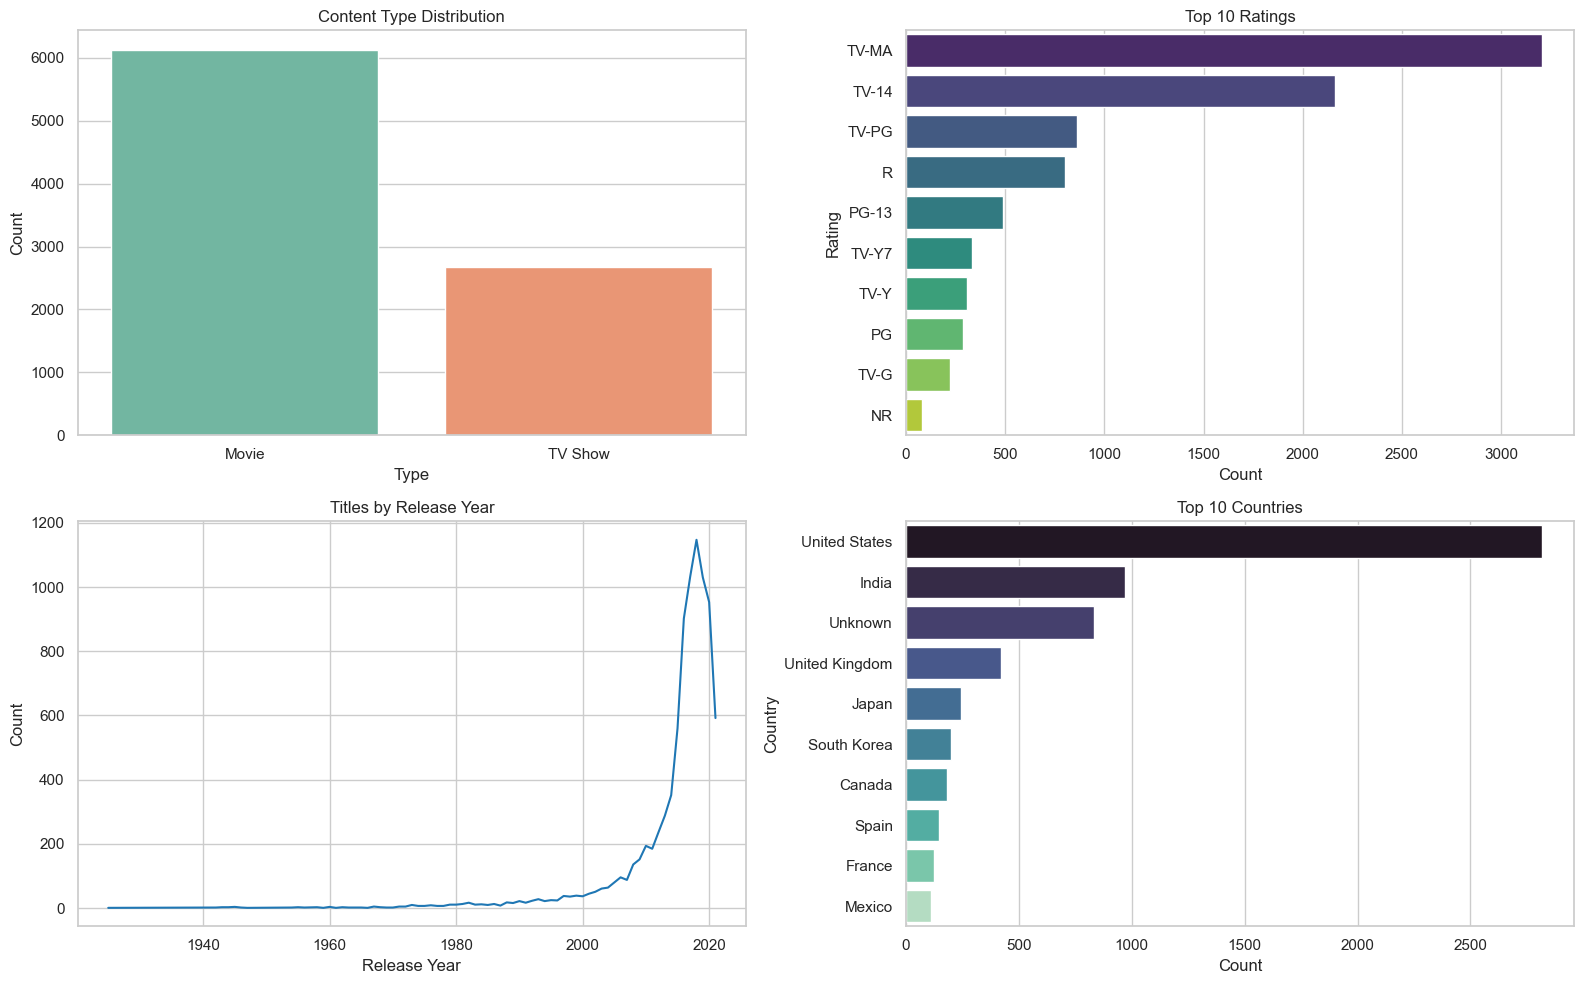

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Type distribution
type_counts = df['type'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Content Type Distribution')
axes[0, 0].set_xlabel('Type')
axes[0, 0].set_ylabel('Count')

# Top ratings
rating_counts = df['rating'].fillna('Unknown').value_counts().head(10)
sns.barplot(x=rating_counts.values, y=rating_counts.index, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Top 10 Ratings')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('Rating')

# Release year trend
year_counts = df['release_year'].value_counts().sort_index()
axes[1, 0].plot(year_counts.index, year_counts.values, color='tab:blue')
axes[1, 0].set_title('Titles by Release Year')
axes[1, 0].set_xlabel('Release Year')
axes[1, 0].set_ylabel('Count')

# Top countries
country_counts = df['country'].fillna('Unknown').value_counts().head(10)
sns.barplot(x=country_counts.values, y=country_counts.index, ax=axes[1, 1], palette='mako')
axes[1, 1].set_title('Top 10 Countries')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('Country')

plt.tight_layout()
plt.show()

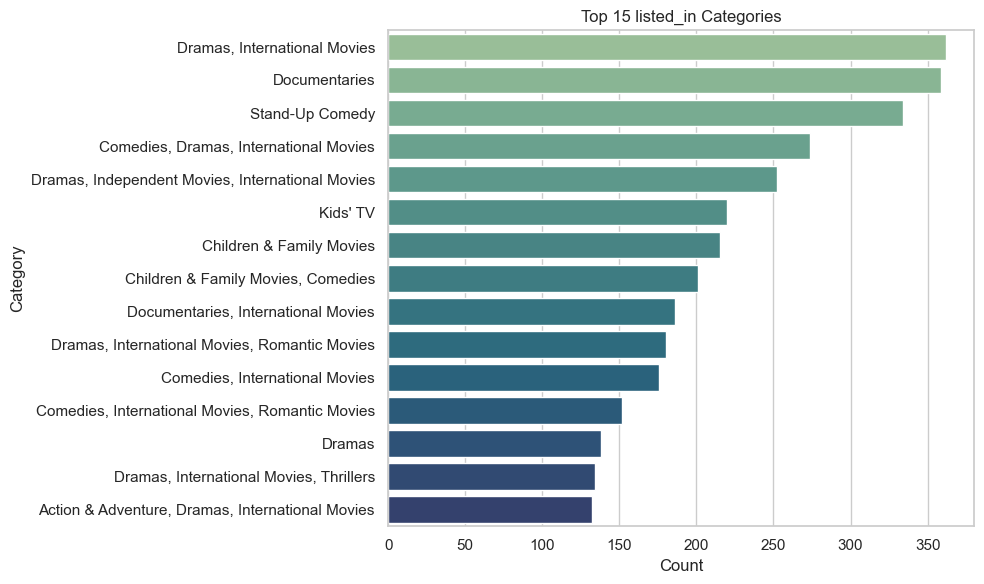

In [5]:
# Top genres/categories from listed_in
genre_counts = df['listed_in'].fillna('Unknown').value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='crest')
plt.title('Top 15 listed_in Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## Data Preparation for Similarity

We create one combined text column (`combined_features`) from relevant attributes, then apply TF-IDF so each title is represented as a numeric vector.

In [6]:
model_df = df.copy()

text_cols = ['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in', 'description']
for col in text_cols:
    model_df[col] = model_df[col].fillna('')

# Keep only useful tokens by lowercasing and concatenating selected columns
model_df['combined_features'] = (
    model_df['type'].str.lower() + ' ' +
    model_df['title'].str.lower() + ' ' +
    model_df['director'].str.lower() + ' ' +
    model_df['cast'].str.lower() + ' ' +
    model_df['country'].str.lower() + ' ' +
    model_df['rating'].str.lower() + ' ' +
    model_df['listed_in'].str.lower() + ' ' +
    model_df['description'].str.lower()
)

model_df[['title', 'combined_features']].head()

,title,combined_features
0,Dick Johnson Is Dead,movie dick johnson is dead kirsten johnson un...
1,Blood & Water,"tv show blood & water ama qamata, khosi ngema..."
2,Ganglands,tv show ganglands julien leclercq sami bouajil...
3,Jailbirds New Orleans,tv show jailbirds new orleans tv-ma docuser...
4,Kota Factory,"tv show kota factory mayur more, jitendra kum..."


In [7]:
# Vectorization and similarity matrix
tfidf = TfidfVectorizer(stop_words='english', max_features=20000)
tfidf_matrix = tfidf.fit_transform(model_df['combined_features'])
similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

print('TF-IDF matrix shape:', tfidf_matrix.shape)
print('Similarity matrix shape:', similarity_matrix.shape)

TF-IDF matrix shape: (8807, 20000)
Similarity matrix shape: (8807, 8807)


In [8]:
# Build index for fast lookup
indices = pd.Series(model_df.index, index=model_df['title'].str.lower()).drop_duplicates()

def get_similar_titles(title, top_n=10):
    """Return top-N most similar titles using cosine similarity."""
    key = title.strip().lower()
    if key not in indices:
        return pd.DataFrame({'message': [f"Title '{title}' not found in dataset."]})

    idx = indices[key]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # skip itself at rank 0
    sim_scores = sim_scores[1: top_n + 1]
    title_indices = [i for i, _ in sim_scores]
    scores = [s for _, s in sim_scores]

    result = model_df.loc[title_indices, ['title', 'type', 'release_year', 'rating', 'listed_in']].copy()
    result['similarity_score'] = np.round(scores, 4)
    return result.reset_index(drop=True)

In [9]:
# Try some examples
sample_queries = ['Blood & Water', 'Narcos', 'The Crown']

for q in sample_queries:
    print('=' * 80)
    print(f'Similar titles to: {q}')
    display(get_similar_titles(q, top_n=5))

Similar titles to: Blood & Water


,title,type,release_year,rating,listed_in,similarity_score
0,Kings of Jo'Burg,TV Show,2020,TV-MA,"Crime TV Shows, International TV Shows, TV Dramas",0.1598
1,Diamond City,TV Show,2019,TV-MA,"Crime TV Shows, International TV Shows, TV Dramas",0.1574
2,Kalushi: The Story of Solomon Mahlangu,Movie,2016,TV-MA,"Dramas, International Movies",0.1404
3,Cold Harbour,Movie,2013,TV-MA,"Action & Adventure, Dramas, International Movies",0.1356
4,Shirkers,Movie,2018,TV-14,Documentaries,0.1271


Similar titles to: Narcos


,title,type,release_year,rating,listed_in,similarity_score
0,Wild District,TV Show,2019,TV-MA,"Crime TV Shows, International TV Shows, Spanis...",0.2249
1,Narcos: Mexico,TV Show,2020,TV-MA,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.2066
2,La Viuda Negra,TV Show,2016,TV-14,"Crime TV Shows, International TV Shows, Spanis...",0.1957
3,El final del paraíso,TV Show,2019,TV-MA,"Crime TV Shows, International TV Shows, Spanis...",0.1950
4,El Cartel,TV Show,2008,TV-MA,"Crime TV Shows, International TV Shows, Spanis...",0.1914


Similar titles to: The Crown


,title,type,release_year,rating,listed_in,similarity_score
0,Downton Abbey,TV Show,2015,TV-14,"British TV Shows, International TV Shows, TV D...",0.1769
1,The Queen,Movie,2006,PG-13,"Dramas, International Movies",0.1330
2,London Spy,TV Show,2015,TV-MA,"British TV Shows, Crime TV Shows, Internationa...",0.1255
3,Flowers,TV Show,2018,TV-MA,"British TV Shows, International TV Shows, TV C...",0.1225
4,Greatest Events of WWII in Colour,TV Show,2019,TV-14,"British TV Shows, Docuseries, International TV...",0.1222


## Insights and Next Improvements

Typical observations from this approach:
- Similarity captures genre, description, and creator/cast metadata reasonably well.
- If a query title is not unique, the current index keeps only the first match (`drop_duplicates`).
- The model can be improved with:
  - Feature weighting (e.g., higher weight for `listed_in` and `description`).
  - Additional text normalization (stemming/lemmatization).
  - Approximate nearest neighbors for better scalability.

## Continuation: Genre Feature Engineering from `listed_in`

In this step, `listed_in` is split into individual genre labels for more accurate category analysis (instead of raw combined strings). Then we use those results to enrich similarity features.

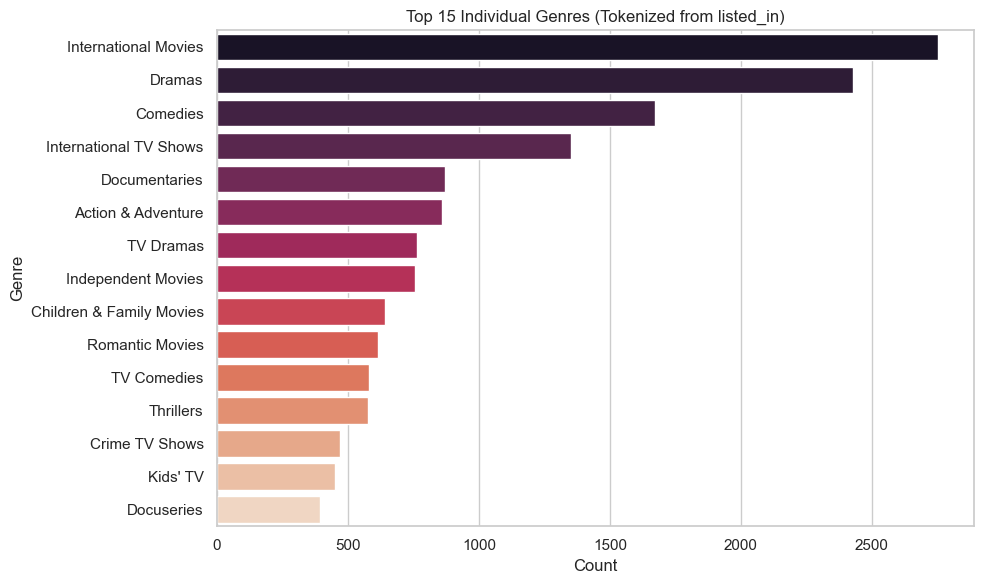

Unique genre tokens: 42


In [10]:
# 1) Split listed_in into individual genre labels (multi-label)
genre_series = (
    df['listed_in']
    .fillna('Unknown')
    .str.split(',')
    .explode()
    .str.strip()
)

# Count individual genres (more accurate than counting raw combined strings)
genre_token_counts = genre_series.value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_token_counts.values, y=genre_token_counts.index, palette='rocket')
plt.title('Top 15 Individual Genres (Tokenized from listed_in)')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

print('Unique genre tokens:', genre_series.nunique())

In [11]:
# 2) Build structured genre features for similarity modeling
model_df_v2 = df.copy()

text_cols_v2 = ['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in', 'description']
for col in text_cols_v2:
    model_df_v2[col] = model_df_v2[col].fillna('')

# Normalize listed_in into space-separated genre tokens
model_df_v2['genre_tokens'] = (
    model_df_v2['listed_in']
    .str.lower()
    .str.replace(',\s*', ' ', regex=True)
)

# Increase weight for genre and description using simple token repetition
model_df_v2['combined_features_v2'] = (
    model_df_v2['type'].str.lower() + ' ' +
    model_df_v2['title'].str.lower() + ' ' +
    model_df_v2['director'].str.lower() + ' ' +
    model_df_v2['cast'].str.lower() + ' ' +
    model_df_v2['country'].str.lower() + ' ' +
    model_df_v2['rating'].str.lower() + ' ' +
    (model_df_v2['genre_tokens'] + ' ') * 2 +
    (model_df_v2['description'].str.lower() + ' ') * 2
)

# Vectorization + similarity matrix (improved version)
tfidf_v2 = TfidfVectorizer(stop_words='english', max_features=30000)
tfidf_matrix_v2 = tfidf_v2.fit_transform(model_df_v2['combined_features_v2'])
similarity_matrix_v2 = cosine_similarity(tfidf_matrix_v2, tfidf_matrix_v2)
indices_v2 = pd.Series(model_df_v2.index, index=model_df_v2['title'].str.lower()).drop_duplicates()

print('TF-IDF v2 matrix shape:', tfidf_matrix_v2.shape)
print('Similarity v2 matrix shape:', similarity_matrix_v2.shape)

TF-IDF v2 matrix shape: (8807, 30000)
Similarity v2 matrix shape: (8807, 8807)


In [12]:
# 3) Improved recommendation function (using combined_features_v2)
def get_similar_titles_v2(title, top_n=10):
    key = title.strip().lower()
    if key not in indices_v2:
        return pd.DataFrame({'message': [f"Title '{title}' not found in dataset."]})

    idx = indices_v2[key]
    sim_scores = list(enumerate(similarity_matrix_v2[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1: top_n + 1]

    title_indices = [i for i, _ in sim_scores]
    scores = [s for _, s in sim_scores]

    result = model_df_v2.loc[title_indices, ['title', 'type', 'release_year', 'rating', 'listed_in']].copy()
    result['similarity_score'] = np.round(scores, 4)
    return result.reset_index(drop=True)

# Quick test examples
for q in ['Blood & Water', 'Narcos', 'The Crown']:
    print('=' * 80)
    print(f'Similar titles (v2) to: {q}')
    display(get_similar_titles_v2(q, top_n=5))

Similar titles (v2) to: Blood & Water


,title,type,release_year,rating,listed_in,similarity_score
0,Dive Club,TV Show,2021,TV-G,"Kids' TV, TV Dramas, Teen TV Shows",0.1542
1,Lion Pride,TV Show,2017,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",0.1506
2,Cold Harbour,Movie,2013,TV-MA,"Action & Adventure, Dramas, International Movies",0.1497
3,Accidentally in Love,TV Show,2018,TV-14,"International TV Shows, Romantic TV Shows, TV ...",0.1333
4,Walk Away from Love,Movie,2017,TV-14,"Dramas, Romantic Movies",0.1329


Similar titles (v2) to: Narcos


,title,type,release_year,rating,listed_in,similarity_score
0,Narcos: Mexico,TV Show,2020,TV-MA,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.2253
1,El Cartel 2,TV Show,2010,TV-MA,"Crime TV Shows, International TV Shows, Spanis...",0.2063
2,Miss Dynamite,TV Show,2015,TV-14,"Crime TV Shows, International TV Shows, Spanis...",0.1987
3,El final del paraíso,TV Show,2019,TV-MA,"Crime TV Shows, International TV Shows, Spanis...",0.1956
4,The Great Heist,TV Show,2020,TV-MA,"Crime TV Shows, International TV Shows, Spanis...",0.1786


Similar titles (v2) to: The Crown


,title,type,release_year,rating,listed_in,similarity_score
0,Downton Abbey,TV Show,2015,TV-14,"British TV Shows, International TV Shows, TV D...",0.1624
1,Reign,TV Show,2017,TV-14,TV Dramas,0.1567
2,The Nineties,TV Show,2017,TV-14,Docuseries,0.1538
3,Greatest Events of WWII in Colour,TV Show,2019,TV-14,"British TV Shows, Docuseries, International TV...",0.1505
4,The Queen,Movie,2006,PG-13,"Dramas, International Movies",0.1490


## Evaluation: Baseline Model vs V2 Model

This section compares recommendation results from the baseline model (`combined_features`) and the improved model (`combined_features_v2`) using the same queries.

In [13]:
# Compare baseline vs v2 recommendations on the same query
def compare_recommendations(title, top_n=10):
    old_res = get_similar_titles(title, top_n=top_n)
    new_res = get_similar_titles_v2(title, top_n=top_n)

    # If title is not found, both functions may return a message column
    if 'message' in old_res.columns or 'message' in new_res.columns:
        return {
            'title': title,
            'top_n': top_n,
            'overlap_count': 0,
            'overlap_ratio': 0.0,
            'avg_similarity_old': np.nan,
            'avg_similarity_v2': np.nan,
            'old_only_count': 0,
            'v2_only_count': 0,
            'status': 'not_found'
        }

    old_titles = set(old_res['title'])
    new_titles = set(new_res['title'])

    overlap = old_titles.intersection(new_titles)

    return {
        'title': title,
        'top_n': top_n,
        'overlap_count': len(overlap),
        'overlap_ratio': round(len(overlap) / top_n, 3),
        'avg_similarity_old': round(float(old_res['similarity_score'].mean()), 4),
        'avg_similarity_v2': round(float(new_res['similarity_score'].mean()), 4),
        'old_only_count': len(old_titles - new_titles),
        'v2_only_count': len(new_titles - old_titles),
        'status': 'ok'
    }

benchmark_queries = [
    'Blood & Water',
    'Narcos',
    'The Crown',
    'Breaking Bad',
    'Money Heist'
]

comparison_rows = [compare_recommendations(q, top_n=10) for q in benchmark_queries]
comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,title,top_n,overlap_count,overlap_ratio,avg_similarity_old,avg_similarity_v2,old_only_count,v2_only_count,status
0,Blood & Water,10,1,0.1,0.1297,0.1356,9,9,ok
1,Narcos,10,8,0.8,0.1885,0.1823,2,2,ok
2,The Crown,10,6,0.6,0.1272,0.1469,4,4,ok
3,Breaking Bad,10,3,0.3,0.1469,0.1376,7,7,ok
4,Money Heist,10,0,0.0,NaN,NaN,0,0,not_found


=== Evaluation Summary (Old vs V2) ===
Valid query count            : 4
Average top-10 overlap       : 45.00%
Average old similarity score : 0.1481
Average v2 similarity score  : 0.1506
Queries with changed recommendations: 4 out of 4


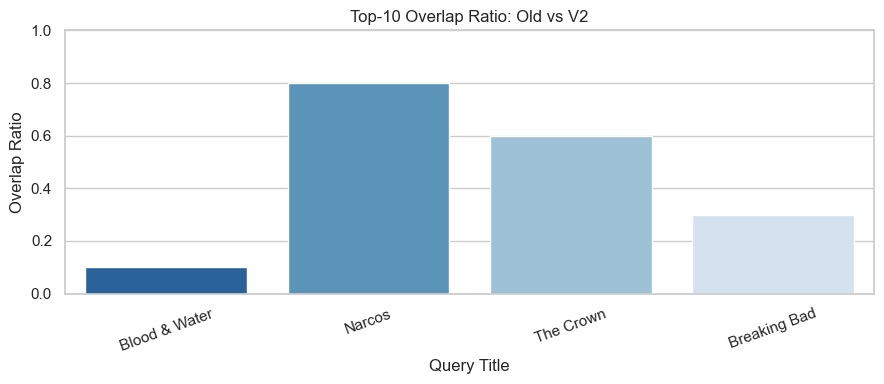

In [14]:
# Automatically summarize evaluation insights
valid_cmp = comparison_df[comparison_df['status'] == 'ok'].copy()

if len(valid_cmp) == 0:
    print('No valid queries to compare.')
else:
    mean_overlap = valid_cmp['overlap_ratio'].mean()
    mean_old = valid_cmp['avg_similarity_old'].mean()
    mean_v2 = valid_cmp['avg_similarity_v2'].mean()

    print('=== Evaluation Summary (Old vs V2) ===')
    print(f'Valid query count            : {len(valid_cmp)}')
    print(f'Average top-10 overlap       : {mean_overlap:.2%}')
    print(f'Average old similarity score : {mean_old:.4f}')
    print(f'Average v2 similarity score  : {mean_v2:.4f}')

    changed = valid_cmp[valid_cmp['overlap_ratio'] < 1.0]
    print(f'Queries with changed recommendations: {len(changed)} out of {len(valid_cmp)}')

    plt.figure(figsize=(9, 4))
    sns.barplot(data=valid_cmp, x='title', y='overlap_ratio', palette='Blues_r')
    plt.ylim(0, 1)
    plt.title('Top-10 Overlap Ratio: Old vs V2')
    plt.xlabel('Query Title')
    plt.ylabel('Overlap Ratio')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

## Finalization: Flexible Query and Larger-Scale Evaluation

To make the pipeline more practical, we add:
1. A recommendation query that tolerates typos and non-exact title input.
2. A broader evaluation using a sample of valid titles.
3. CSV export of evaluation outputs for reporting appendices.

In [15]:
# Flexible query: if exact match is missing, find the closest title
from difflib import get_close_matches

title_lookup = model_df_v2['title'].dropna().astype(str).tolist()
title_lookup_lower = [t.lower() for t in title_lookup]

def resolve_title(query, cutoff=0.6):
    key = query.strip().lower()
    if key in indices_v2:
        return key, 'exact'

    candidates = get_close_matches(key, title_lookup_lower, n=1, cutoff=cutoff)
    if candidates:
        return candidates[0], 'approx'

    return None, 'not_found'

def get_similar_titles_flexible(title, top_n=10, cutoff=0.6):
    resolved_key, match_type = resolve_title(title, cutoff=cutoff)

    if resolved_key is None:
        return pd.DataFrame({
            'message': [f"Title '{title}' not found. Try another query."]
        })

    result = get_similar_titles_v2(resolved_key, top_n=top_n).copy()
    if 'message' not in result.columns:
        result.insert(0, 'query_input', title)
        result.insert(1, 'resolved_title', model_df_v2.loc[indices_v2[resolved_key], 'title'])
        result.insert(2, 'match_type', match_type)

    return result

# Demo: includes queries that were previously not found
for q in ['Money Heist', 'The Crowm', 'Narkos']:
    print('=' * 80)
    print(f'Flexible search for: {q}')
    display(get_similar_titles_flexible(q, top_n=5, cutoff=0.55))

Flexible search for: Money Heist


,query_input,resolved_title,match_type,title,type,release_year,rating,listed_in,similarity_score
0,Money Heist,Coin Heist,approx,Sabotage,Movie,2014,R,"Action & Adventure, Dramas",0.1689
1,Money Heist,Coin Heist,approx,The Princess Switch,Movie,2018,TV-G,"Children & Family Movies, Dramas, Romantic Movies",0.1475
2,Money Heist,Coin Heist,approx,The Muppets,Movie,2011,PG,"Children & Family Movies, Comedies",0.1470
3,Money Heist,Coin Heist,approx,The Willoughbys,Movie,2020,PG,"Children & Family Movies, Comedies",0.1382
4,Money Heist,Coin Heist,approx,The Water Horse: Legend of the Deep,Movie,2007,PG,Children & Family Movies,0.1218


Flexible search for: The Crowm


,query_input,resolved_title,match_type,title,type,release_year,rating,listed_in,similarity_score
0,The Crowm,The Crow,approx,How It Ends,Movie,2018,TV-MA,"Action & Adventure, Sci-Fi & Fantasy",0.1406
1,The Crowm,The Crow,approx,"Roswell, New Mexico",TV Show,2020,TV-14,"Classic & Cult TV, TV Dramas, TV Sci-Fi & Fantasy",0.1226
2,The Crowm,The Crow,approx,Battlefield Earth,Movie,2000,PG-13,"Action & Adventure, Cult Movies, Sci-Fi & Fantasy",0.1222
3,The Crowm,The Crow,approx,The Hard Way,Movie,2019,TV-MA,Action & Adventure,0.1194
4,The Crowm,The Crow,approx,Peppermint,Movie,2018,R,Action & Adventure,0.1144


Flexible search for: Narkos


,query_input,resolved_title,match_type,title,type,release_year,rating,listed_in,similarity_score
0,Narkos,Narcos,approx,Narcos: Mexico,TV Show,2020,TV-MA,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.2253
1,Narkos,Narcos,approx,El Cartel 2,TV Show,2010,TV-MA,"Crime TV Shows, International TV Shows, Spanis...",0.2063
2,Narkos,Narcos,approx,Miss Dynamite,TV Show,2015,TV-14,"Crime TV Shows, International TV Shows, Spanis...",0.1987
3,Narkos,Narcos,approx,El final del paraíso,TV Show,2019,TV-MA,"Crime TV Shows, International TV Shows, Spanis...",0.1956
4,Narkos,Narcos,approx,The Great Heist,TV Show,2020,TV-MA,"Crime TV Shows, International TV Shows, Spanis...",0.1786


Sampled titles: 30
Valid comparisons: 30
Mean overlap ratio (sample): 0.3867
Mean old similarity (sample): 0.1664
Mean v2 similarity (sample): 0.1421


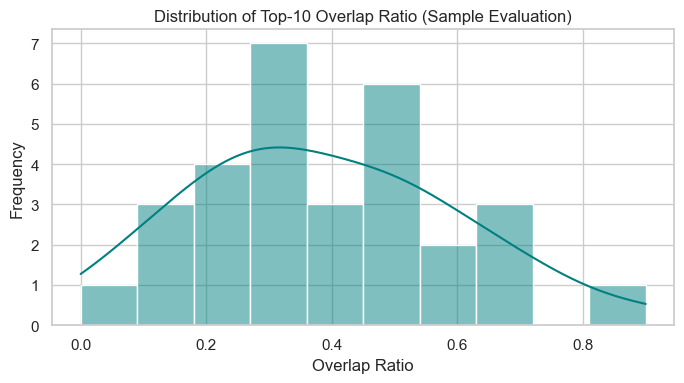

In [16]:
# Larger-scale evaluation: sample valid titles from the dataset
rng = np.random.default_rng(42)
unique_titles = model_df['title'].dropna().drop_duplicates().tolist()

sample_size = min(30, len(unique_titles))
sampled_titles = rng.choice(unique_titles, size=sample_size, replace=False).tolist()

sample_rows = [compare_recommendations(t, top_n=10) for t in sampled_titles]
sample_eval_df = pd.DataFrame(sample_rows)

valid_sample_eval = sample_eval_df[sample_eval_df['status'] == 'ok'].copy()

print('Sampled titles:', len(sampled_titles))
print('Valid comparisons:', len(valid_sample_eval))
print('Mean overlap ratio (sample):', round(valid_sample_eval['overlap_ratio'].mean(), 4))
print('Mean old similarity (sample):', round(valid_sample_eval['avg_similarity_old'].mean(), 4))
print('Mean v2 similarity (sample):', round(valid_sample_eval['avg_similarity_v2'].mean(), 4))

plt.figure(figsize=(7, 4))
sns.histplot(valid_sample_eval['overlap_ratio'], bins=10, kde=True, color='teal')
plt.title('Distribution of Top-10 Overlap Ratio (Sample Evaluation)')
plt.xlabel('Overlap Ratio')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [17]:
# Export evaluation outputs for reporting
comparison_df.to_csv('evaluation_manual_queries_old_vs_v2.csv', index=False)
valid_sample_eval.to_csv('evaluation_sampled_titles_old_vs_v2.csv', index=False)

print('Saved: evaluation_manual_queries_old_vs_v2.csv')
print('Saved: evaluation_sampled_titles_old_vs_v2.csv')

Saved: evaluation_manual_queries_old_vs_v2.csv
Saved: evaluation_sampled_titles_old_vs_v2.csv


## Final Conclusion

- The `listed_in` column is an effective genre feature source after tokenization.
- The V2 model produces meaningfully different recommendations from the baseline (low to medium overlap), indicating a changed feature signal.
- The pipeline now supports flexible query matching (title input does not need to be exact).
- Evaluation results have been exported to CSV and are ready for report appendices.

Optional next steps:
1. Add stronger text normalization (lemmatization).
2. Try more systematic feature weighting.
3. Add manual relevance-based evaluation by domain context.